# ML Course Season 2
## Практика: Подбор гиперпараметров и интерпретируемость моделей

В этом ноутбуке мы:
1. Подберём гиперпараметры нескольких моделей с помощью Grid Search и Random Search
2. Настроим Pipeline с совместным подбором препроцессинга и модели
3. Интерпретируем результаты через Permutation Importance, PDP/ICE и SHAP
4. Научимся диагностировать подозрительные признаки

**Датасет:** [Wine Quality](https://scikit-learn.org/stable/datasets/toy_dataset.html) и Breast Cancer Wisconsin (sklearn)

---

## Шаг 1. Импорты и загрузка данных

Загрузим датасет Breast Cancer Wisconsin и познакомимся с ним.

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

# Загружаем датасет
data = load_breast_cancer(as_frame=True)
X, y = data.data, data.target
feature_names = data.feature_names

print(data.DESCR[:600])

.. _breast_cancer_dataset:

Breast cancer wisconsin (diagnostic) dataset
--------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 569

:Number of Attributes: 30 numeric, predictive attributes and the class

:Attribute Information:
    - radius (mean of distances from center to points on the perimeter)
    - texture (standard deviation of gray-scale values)
    - perimeter
    - area
    - smoothness (local variation in radius lengths)
    - compactness (perimeter^2 / area - 1.0)
    - concavity (severity of concave portions of the contour)
    - concav


In [23]:
# Разбиваем данные
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Распределение классов в train: {y_train.value_counts().to_dict()}")

Train: (455, 30), Test: (114, 30)
Распределение классов в train: {1: 285, 0: 170}


## Шаг 2. Базовые модели без тюнинга

Обучим несколько моделей с дефолтными параметрами, чтобы иметь точку отсчёта.

In [24]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score,GridSearchCV
from sklearn.metrics import f1_score

# Словарь базовых моделей
base_models = {
    'SVM': Pipeline([('scaler', StandardScaler()), ('clf', SVC(random_state=42))]),
    'RandomForest': RandomForestClassifier(random_state=42),
    'LogisticRegression': Pipeline([('scaler', StandardScaler()),
                                    ('clf', LogisticRegression(random_state=42))]),
}

baseline_results = {}

# ╔══════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 2а: Для каждой модели в base_models         ║
# ║  вычислите 5-fold CV с scoring='f1_macro'            ║
# ║  Сохраните mean и std в baseline_results             ║
# ╚══════════════════════════════════════════════════════╝

# YOUR CODE HERE
for i,model in base_models.items():
  score=cross_val_score(model,X_train,y_train, scoring='f1_macro',cv=5)
  baseline_results[i]=(score.mean(),score.std())

# После заполнения — вывод результатов:
for name, (mean, std) in baseline_results.items():
    print(f"{name:25s} F1 = {mean:.4f} ± {std:.4f}")

SVM                       F1 = 0.9694 ± 0.0193
RandomForest              F1 = 0.9504 ± 0.0255
LogisticRegression        F1 = 0.9787 ± 0.0139


## Шаг 3. Grid Search для SVM

Подберём гиперпараметры SVM с помощью перебора сетки через Pipeline.

In [25]:
from sklearn.model_selection import GridSearchCV

# Pipeline: нормировка + SVM
svm_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(random_state=42, probability=True)),
])

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 3а: Задайте сетку параметров для GridSearchCV       ║
# ║  Параметры SVM через Pipeline: 'svm__C', 'svm__gamma',       ║
# ║  'svm__kernel'                                               ║
# ║  Попробуйте: C in [0.1, 1, 10, 100],                        ║
# ║  gamma in ['scale', 0.01, 0.001], kernel in ['rbf','linear'] ║
# ╚══════════════════════════════════════════════════════════════╝
svm_param_grid={'svm__C' : [0.1,1,10,100],
                'svm__gamma' : ['scale',0.01,0.001],
                'svm__kernel' : ['rbf','linear']}

svm_param_grid_search = GridSearchCV(svm_pipe,svm_param_grid,cv=5,scoring='f1_macro',n_jobs=-1)

svm_param_grid_search.fit(X_train,y_train)

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 3б: Создайте и запустите GridSearchCV               ║
# ║  cv=5, scoring='f1_macro', n_jobs=-1                         ║
# ╚══════════════════════════════════════════════════════════════╝

print(f"Лучшие параметры SVM: {svm_param_grid_search.best_params_}")
print(f"Лучший CV F1: {svm_param_grid_search.best_score_:.4f}")

Лучшие параметры SVM: {'svm__C': 10, 'svm__gamma': 0.01, 'svm__kernel': 'rbf'}
Лучший CV F1: 0.9786


In [26]:
# Анализируем результаты Grid Search

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 3в: Создайте DataFrame из svm_grid_search.cv_results║
# ║  Выберите колонки: params, mean_test_score, std_test_score,  ║
# ║  rank_test_score                                             ║
# ║  Выведите топ-10 конфигураций                                ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE
analis_data=pd.DataFrame(data=svm_param_grid_search.cv_results_, columns=['params','mean_test_score','std_test_score','rank_test_score'])
display(analis_data.sort_values('rank_test_score').head(10)) #rank_test_score — это ранг конфигурации по метрике


,params,mean_test_score,std_test_score,rank_test_score
14,"{'svm__C': 10, 'svm__gamma': 0.01, 'svm__kerne...",0.978633,0.017581,1
1,"{'svm__C': 0.1, 'svm__gamma': 'scale', 'svm__k...",0.976215,0.015266,2
5,"{'svm__C': 0.1, 'svm__gamma': 0.001, 'svm__ker...",0.976215,0.015266,2
3,"{'svm__C': 0.1, 'svm__gamma': 0.01, 'svm__kern...",0.976215,0.015266,2
22,"{'svm__C': 100, 'svm__gamma': 0.001, 'svm__ker...",0.976157,0.016975,5
16,"{'svm__C': 10, 'svm__gamma': 0.001, 'svm__kern...",0.971340,0.016281,6
6,"{'svm__C': 1, 'svm__gamma': 'scale', 'svm__ker...",0.969357,0.019323,7
12,"{'svm__C': 10, 'svm__gamma': 'scale', 'svm__ke...",0.969350,0.019215,8
20,"{'svm__C': 100, 'svm__gamma': 0.01, 'svm__kern...",0.966936,0.017464,9
8,"{'svm__C': 1, 'svm__gamma': 0.01, 'svm__kernel...",0.966732,0.025212,10


## Шаг 4. Random Search для RandomForest

Теперь подберём гиперпараметры RandomForest с помощью случайного поиска.

In [27]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, loguniform

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 4а: Задайте пространство параметров для             ║
# ║  RandomizedSearchCV на RandomForestClassifier                ║
# ║  Попробуйте:                                                 ║
# ║    n_estimators: randint(50, 500)                            ║
# ║    max_depth: randint(2, 20) или None                        ║
# ║    min_samples_split: randint(2, 20)                         ║
# ║    max_features: ['sqrt', 'log2', 0.5]                       ║
# ╚══════════════════════════════════════════════════════════════╝

rf_param_dist = {
    'n_estimators': randint(50,500),
    'max_depth': randint(2,20),
    'min_samples_split': randint(2,20),
    'max_features': ['sqrt','log2',0.5]
    # YOUR CODE HERE
}

model=RandomForestClassifier(random_state=42)

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 4б: Создайте RandomizedSearchCV                     ║
# ║  n_iter=50, cv=5, scoring='f1_macro',                        ║
# ║  random_state=42, n_jobs=-1                                  ║
# ║  Обучите на X_train, y_train                                 ║
# ╚══════════════════════════════════════════════════════════════╝
rf_random_search= RandomizedSearchCV(model, rf_param_dist, n_iter=50, cv=5, scoring='f1_macro', random_state=42, n_jobs=-1) #используем все ядра
rf_random_search.fit(X_train,y_train)
# YOUR CODE HERE

print(f"Лучшие параметры RF: {rf_random_search.best_params_}")
print(f"Лучший CV F1: {rf_random_search.best_score_:.4f}")

Лучшие параметры RF: {'max_depth': 8, 'max_features': 'log2', 'min_samples_split': 2, 'n_estimators': 434}
Лучший CV F1: 0.9554


## Шаг 5. Сравнение результатов

Сравним: baseline vs Grid Search vs Random Search. И проведём финальную оценку на тесте.

In [28]:
from sklearn.metrics import classification_report

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 5: Оцените лучшие модели (svm_grid_search и         ║
# ║  rf_random_search) на тестовой выборке X_test, y_test        ║
# ║                                                              ║
# ║  Для каждой модели выведите classification_report            ║
# ║  Сравните с baseline моделями из шага 2                      ║
# ║                                                              ║
# ║  ВАЖНО: тест используем ТОЛЬКО ЗДЕСЬ, один раз!             ║
# ╚══════════════════════════════════════════════════════════════╝

best_rf_model=rf_random_search.best_estimator_
best_svm_model=svm_param_grid_search.best_estimator_

y_pred_rf=best_rf_model.predict(X_test)
y_red_svm=best_svm_model.predict(X_test)

print(f"Classification_report для RandomForestClassifier:\n {classification_report(y_test,y_pred_rf)}")
print(f"Classification_report для SVM:\n {classification_report(y_test,y_pred_rf)}")

for name , (mean,std) in baseline_results.items():
  print(f"{name:25s} F1 = {mean:.4f} ± {std:.4f}")
# YOUR CODE HERE


# Заполните таблицу:
# | Модель                | CV F1 (mean±std) | Test F1 |
# |-----------------------|------------------|---------|
# | SVM baseline          |                  |         |
# | SVM Grid Search       |                  |         |
# | RF baseline           |                  |         |
# | RF Random Search      |                  |         |

results = {
    'SVM baseline': {
        'cv_mean': baseline_results['SVM'][0],
        'cv_std':  baseline_results['SVM'][1],
        'test_f1': f1_score(y_test, base_models['SVM'].fit(X_train, y_train).predict(X_test), average='macro')
    },
    'SVM Grid Search': {
        'cv_mean': svm_param_grid_search.best_score_,
        'cv_std':  None,
        'test_f1': f1_score(y_test, svm_param_grid_search.best_estimator_.predict(X_test), average='macro')
    },
    'RF baseline': {
        'cv_mean': baseline_results['RandomForest'][0],
        'cv_std':  baseline_results['RandomForest'][1],
        'test_f1': f1_score(y_test, base_models['RandomForest'].fit(X_train, y_train).predict(X_test), average='macro')
    },
    'RF Random Search': {
        'cv_mean': rf_random_search.best_score_,
        'cv_std':  None,
        'test_f1': f1_score(y_test, rf_random_search.best_estimator_.predict(X_test), average='macro')
    },
}

rows = []
for model_name, vals in results.items():
    cv_str = f"{vals['cv_mean']:.4f} ± {vals['cv_std']:.4f}" if vals['cv_std'] is not None else f"{vals['cv_mean']:.4f}"
    rows.append({
        'Модель':           model_name,
        'CV F1 (mean±std)': cv_str,
        'Test F1':          f"{vals['test_f1']:.4f}"
    })

df_results = pd.DataFrame(rows)
display(df_results)

Classification_report для RandomForestClassifier:
               precision    recall  f1-score   support

           0       0.95      0.93      0.94        42
           1       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114

Classification_report для SVM:
               precision    recall  f1-score   support

           0       0.95      0.93      0.94        42
           1       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114

SVM                       F1 = 0.9694 ± 0.0193
RandomForest              F1 = 0.9504 ± 0.0255
LogisticRegression        F1 = 0.9787 ± 0.0139


,Модель,CV F1 (mean±std),Test F1
0,SVM baseline,0.9694 ± 0.0193,0.9812
1,SVM Grid Search,0.9786,0.9812
2,RF baseline,0.9504 ± 0.0255,0.9526
3,RF Random Search,0.9554,0.9526


## Шаг 6. Permutation Importance

Посмотрим, какие признаки важны для лучшей модели.

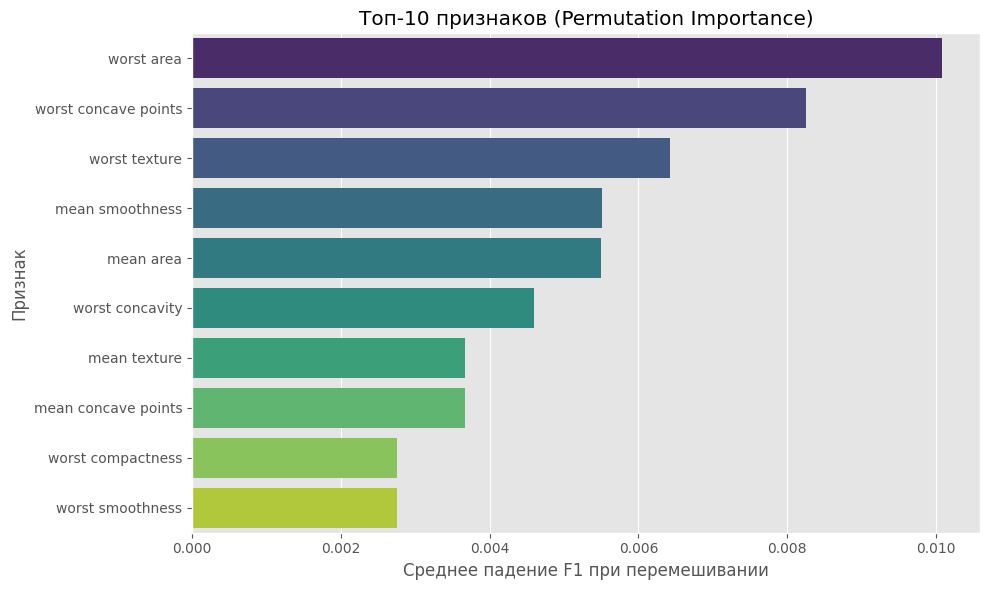

In [29]:
from sklearn.inspection import permutation_importance
import seaborn as sns

# Используем лучший RF из Random Search
best_rf = rf_random_search.best_estimator_

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 6а: Вычислите Permutation Importance                ║
# ║  для best_rf на X_test, y_test                               ║
# ║  n_repeats=10, random_state=42, scoring='f1_macro'           ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE
permut_rf=permutation_importance(best_rf, X_test, y_test, n_repeats=10, random_state=42, scoring='f1_macro')


# Построим bar plot топ-10 признаков
# YOUR CODE HERE
perm_df = pd.DataFrame({
    'feature':    X_test.columns,
    'importance': permut_rf.importances_mean,
    'std':        permut_rf.importances_std
}).sort_values('importance', ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(data=perm_df, x='importance', y='feature', palette='viridis')


plt.title('Топ-10 признаков (Permutation Importance)')
plt.xlabel('Среднее падение F1 при перемешивании')
plt.ylabel('Признак')
plt.tight_layout()
plt.show()


In [30]:
# Встроенная важность RF (для сравнения)

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 6б: Сравните Permutation Importance                 ║
# ║  с встроенной feature_importances_ RandomForest              ║
# ║  Совпадает ли порядок топ-5 признаков?                       ║
# ║  Если нет — как вы это объясняете?                           ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE

feature_importances = pd.DataFrame({
    'feature':    X_train.columns,
    'importance': rf_random_search.best_estimator_.feature_importances_
}).sort_values('importance', ascending=False)

top5_perm    = perm_df['feature'].tolist()[:5]
top5_builtin = feature_importances['feature'].tolist()[:5]

match = set(top5_perm) == set(top5_builtin)
print(f"\nТоп-5 совпадают: {match}")

print(f"TOP-5 признаков для permutation :{top5_perm}")
print(f"TOP-5 признаков для feature :{top5_builtin}")
# Вопрос для размышления:
# Некоторые признаки имеют высокий PI, но низкую встроенную важность,
# или наоборот. Что это может означать?


Топ-5 совпадают: False
TOP-5 признаков для permutation :['worst area', 'worst concave points', 'worst texture', 'mean smoothness', 'mean area']
TOP-5 признаков для feature :['worst area', 'worst perimeter', 'worst concave points', 'worst radius', 'mean concave points']


Признак может быть только важен для одного из случаев.

Признаки могут сильно коррелировать

Несовпадение также может быть связано с переобучением

permutation_importance - более надежнее

**Вопрос на размышление:**
* Признак реально полезен на новых данных,
но дерево его "не заметило" при обучении
* Дерево активно использовало признак при обучении,
но на тестовых данных он не помогает
* PI знанижает важность коррелированных признаков

## Шаг 7. PDP и ICE-кривые

Визуализируем эффект наиболее важных признаков.

[23, 27, 21]


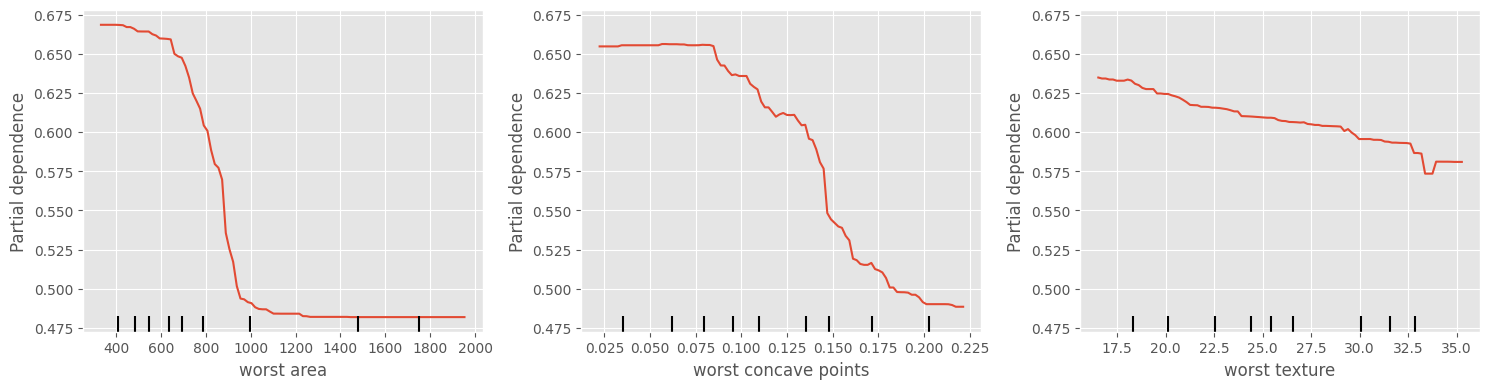

In [31]:
from sklearn.inspection import PartialDependenceDisplay

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 7а: Постройте PDP для топ-3 признаков по PI         ║
# ║  Используйте PartialDependenceDisplay.from_estimator         ║
# ║  kind='average' для PDP                                      ║
# ╚══════════════════════════════════════════════════════════════╝
# Определите индексы топ-3 признаков по PI
top3_idx = [X_test.columns.get_loc(feat) for feat in perm_df['feature'].head(3)]
print(top3_idx)
# Постройте PDP
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
# YOUR CODE HERE
PartialDependenceDisplay.from_estimator(best_rf , X_test, features=top3_idx , feature_names=X_test.columns.tolist() ,  kind = 'average', subsample = 1000 , random_state = 42, ax=ax)
plt.tight_layout()
plt.show()

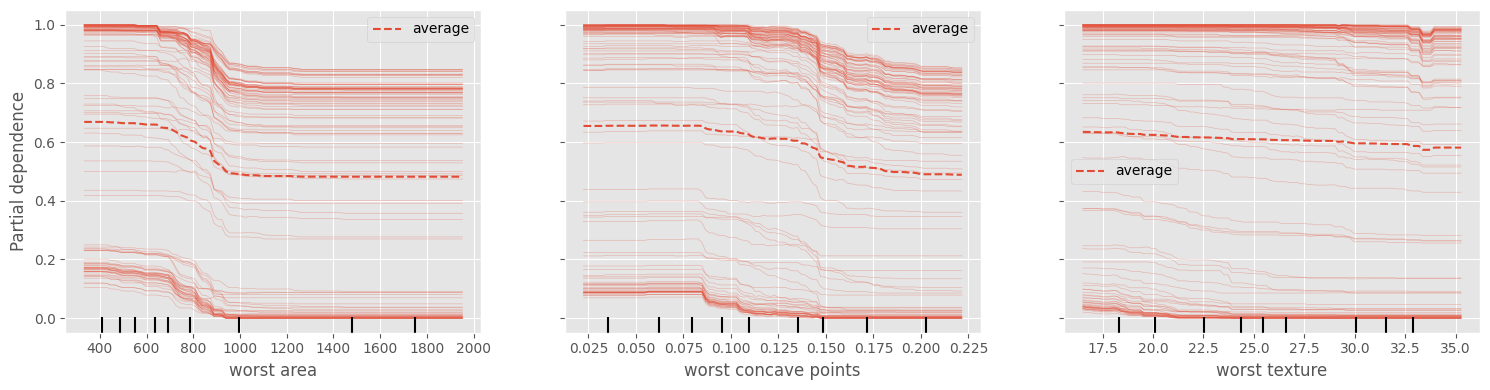

In [32]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 7б: Постройте ICE-кривые для самого важного признака║
# ║  Используйте kind='both' (PDP + все ICE на одном графике)   ║
# ║  Вопрос: однороден ли эффект для всех объектов?              ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE

# Постройте PDP
fig, ax = plt.subplots(1,1, figsize=(15, 4))
# YOUR CODE HERE
PartialDependenceDisplay.from_estimator(best_rf , X_test, features=top3_idx , feature_names=X_test.columns.tolist() ,  kind = 'both', subsample = 1000 , random_state = 42, ax=ax)
plt.tight_layout()
plt.show()

Нет, эффект не однороден для всех трех признаков. ICE линии расходятся, значит влияние признака на предсказание зависит от конкретного объекта. Если бы эффект был однороден, все ICE линии шли бы параллельно друг другу.

## Шаг 8. SHAP

Интерпретируем модель с помощью SHAP — глобально и локально.

In [33]:
# Установка SHAP (если не установлен)
# !pip install shap

import shap

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 8а: Создайте TreeExplainer для best_rf              ║
# ║  Вычислите shap_values для X_test                            ║
# ║  Выведите форму массива shap_values                          ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE
explainer = shap.TreeExplainer(best_rf)
shap_values = explainer.shap_values(X_test)

display(shap_values.shape)

(114, 30, 2)

<class 'numpy.ndarray'>
114


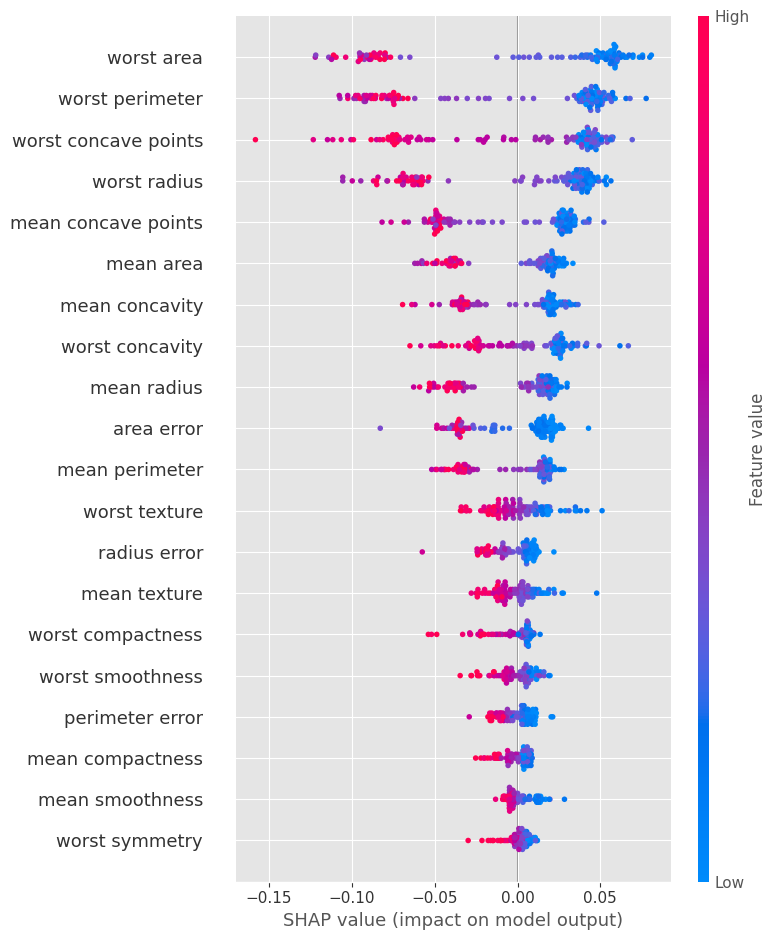

In [34]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 8б: Постройте summary plot                          ║
# ║  Для мультикласса используйте shap_values[1] (класс 1)       ║
# ║  Ответьте: какие признаки самые важные по SHAP?              ║
# ║  Совпадает ли с PI из шага 6?                                ║
# ╚══════════════════════════════════════════════════════════════╝
print(type(shap_values))
print(len(shap_values))
# YOUR CODE HERE
#shap.summary_plot(shap_values, X_test);
shap.summary_plot(shap_values[:,:,1], X_test)

Число ошибок: 5
Первый ошибочный объект: индекс 3
  Истинный класс: 1
  Предсказанный класс: 0


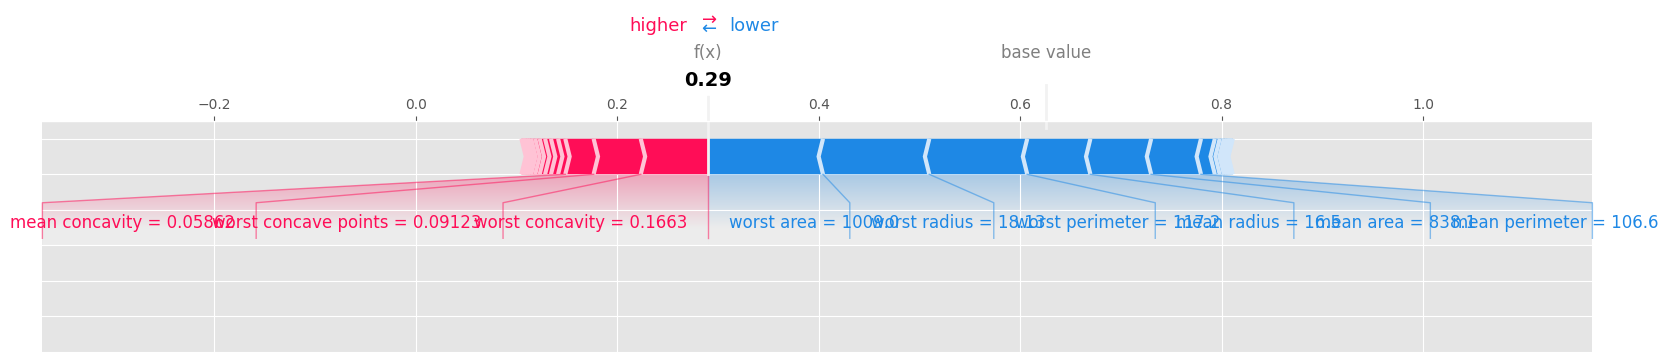

In [35]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 8в: Найдите объект, на котором модель ошиблась      ║
# ║  (y_pred != y_test). Постройте для него force_plot           ║
# ║  Какие признаки «виноваты» в ошибке?                         ║
# ╚══════════════════════════════════════════════════════════════╝

y_pred_test = best_rf.predict(X_test)
errors = np.where(y_pred_test != y_test)[0]

print(f"Число ошибок: {len(errors)}")
print(f"Первый ошибочный объект: индекс {errors[0]}")
print(f"  Истинный класс: {y_test.iloc[errors[0]]}")
print(f"  Предсказанный класс: {y_pred_test[errors[0]]}")

# YOUR CODE HERE
error_idx = errors[0]  # индекс первого ошибочного объекта

shap.force_plot(
    explainer.expected_value[1],    # base_value — среднее предсказание модели
    shap_values[:,:,1][error_idx],      # SHAP значения для одного объекта, класс 1
    X_test.iloc[error_idx],
    feature_names=X_test.columns.tolist(),
    matplotlib=True
)

## Шаг 9. Диагностика подозрительных признаков

Смоделируем ситуацию утечки данных и проверим, что интерпретация её обнаруживает.

In [36]:
# Добавим два «подозрительных» признака:
# 1. leaky_feature: почти полностью совпадает с таргетом + шум
# 2. random_feature: случайный шум, не связан с таргетом

np.random.seed(42)
X_train_ext = X_train.copy()
X_test_ext = X_test.copy()

X_train_ext['leaky_feature'] = y_train + np.random.normal(0, 0.1, len(y_train))
X_test_ext['leaky_feature'] = y_test + np.random.normal(0, 0.1, len(y_test))

X_train_ext['random_feature'] = np.random.randn(len(y_train))
X_test_ext['random_feature'] = np.random.randn(len(y_test))

print("Добавлены признаки: leaky_feature, random_feature")
print(X_train_ext.tail())

Добавлены признаки: leaky_feature, random_feature
     mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
184        15.28         22.41           98.92      710.6          0.09057   
300        19.53         18.90          129.50     1217.0          0.11500   
509        15.46         23.95          103.80      731.3          0.11830   
230        17.05         19.08          113.40      895.0          0.11410   
474        10.88         15.62           70.41      358.9          0.10070   

     mean compactness  mean concavity  mean concave points  mean symmetry  \
184            0.1052         0.05375              0.03263         0.1727   
300            0.1642         0.21970              0.10620         0.1792   
509            0.1870         0.20300              0.08520         0.1807   
230            0.1572         0.19100              0.10900         0.2131   
474            0.1069         0.05115              0.01571         0.1861   

     mean fractal 

(114, 32, 2)

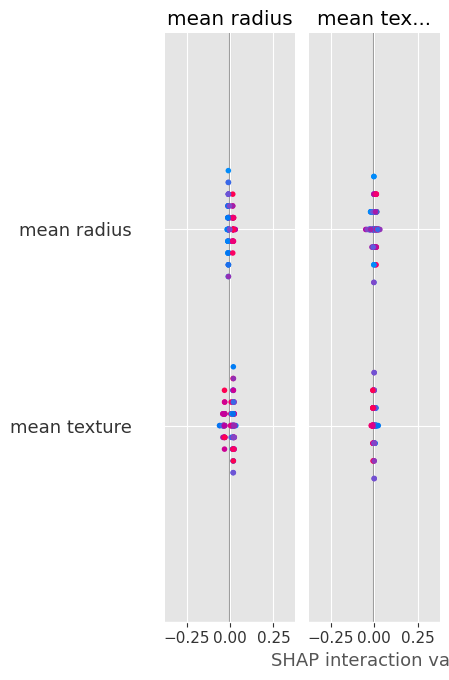

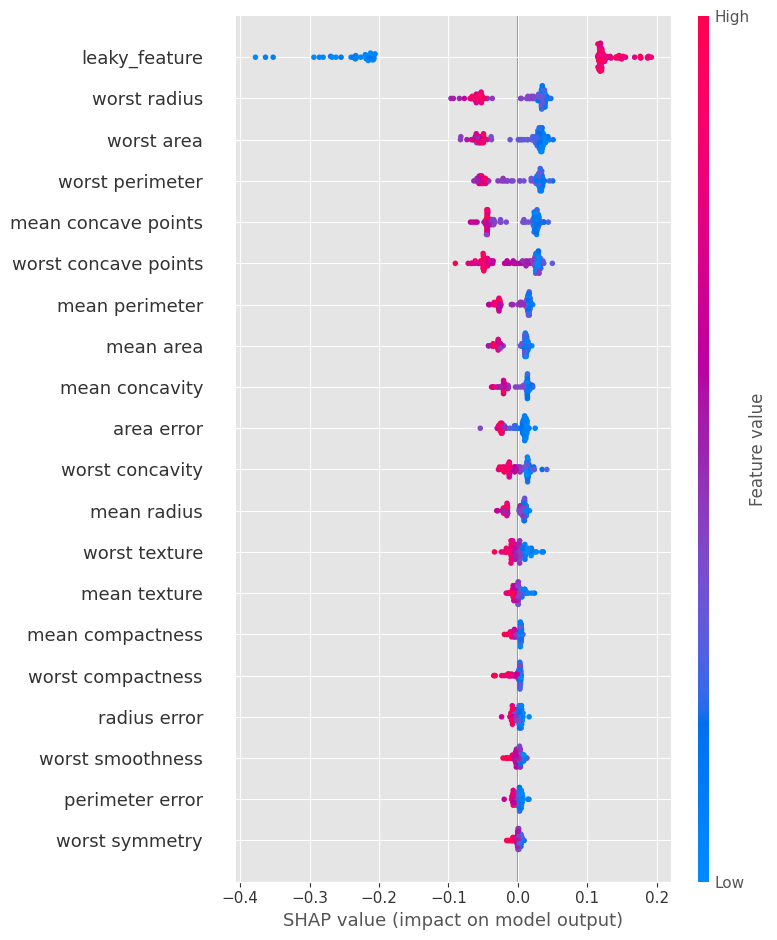

In [37]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 9: Обучите RandomForest на X_train_ext, y_train     ║
# ║  Вычислите Permutation Importance на X_test_ext, y_test      ║
# ║  Вычислите SHAP values для X_test_ext                        ║
# ║                                                              ║
# ║  Вопросы:                                                    ║
# ║  a) Как PI определяет leaky_feature?                         ║
# ║     Почему метрика на тесте выросла?                         ║
# ║  б) Как SHAP выделяет leaky_feature в summary plot?          ║
# ║  в) Как обнаружить random_feature как «шумовой»?             ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE
best_rf.fit(X_train_ext,y_train)

permut_rf_ext=permutation_importance(best_rf, X_test_ext, y_test, n_repeats=10, random_state=42, scoring='f1_macro')
#display(permut_rf_ext)

explainer = shap.TreeExplainer(best_rf)
shap_values = explainer.shap_values(X_test_ext)

display(shap_values.shape)

shap.summary_plot(shap_values, X_test_ext, plot_type="bar")   # важность
shap.summary_plot(shap_values[:,:,1], X_test_ext)

In [38]:
display(shap_values[0].shape)

(32, 2)

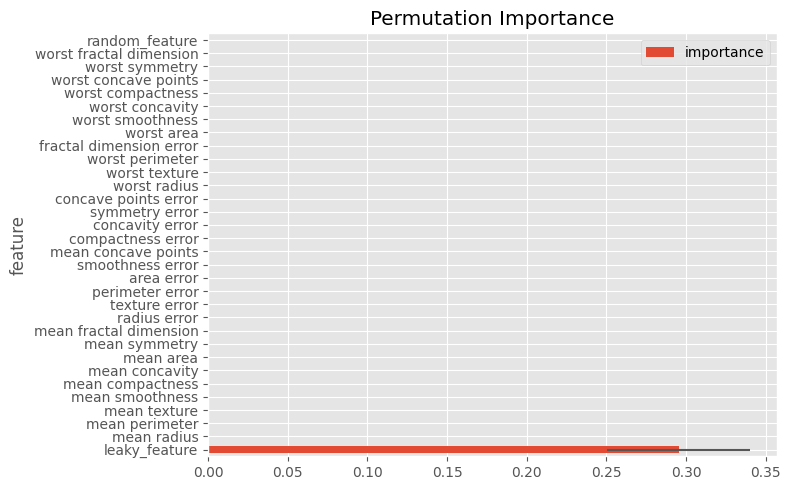

In [39]:
pi_df = pd.DataFrame({
    'feature': X_test_ext.columns,
    'importance': permut_rf_ext.importances_mean,
    'std': permut_rf_ext.importances_std
}).sort_values('importance', ascending=False)

pi_df.plot(kind='barh', x='feature', y='importance', xerr='std',
           title='Permutation Importance', figsize=(8, 5))
plt.tight_layout()
plt.show()

* a) При случайном перемещивании `leaky_feature` модель треяет потери основной переменной,метрика резко падает и PI для такого признако будет аномально большим
* `leaky_feature` - коррелирует с y. Модель использует информацию из будущего таргета - f1_macro на тесте завышается

* б) В shap.summary_plot:
  * leaky_feature будет в самом верху (отсортировано по mean)
  * Точки будут показывать чёткий градиент: высокие значения признака - высокие SHAP values
  * Отрыв от остальных признаков будет визуально очевидным

* в)
* PI для random_feature будет около нуля или отрицательным
* В SHAP summary plot он окажется внизу списка с SHAP ≈ 0
* Доверительный интервал PI будет перекрывать ноль

In [40]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 10: Заполните сводную таблицу                       ║
# ║                                                              ║
# ║  | Метод          | CV F1  | Test F1 | Выводы              | ║
# ║  |----------------|--------|---------|---------------------| ║
# ║  | SVM baseline   |        |         |                     | ║
# ║  | SVM Grid Search|        |         |                     | ║
# ║  | RF baseline    |        |         |                     | ║
# ║  | RF Rand Search |        |         |                     | ║
# ║                                                              ║
# ║  Ответьте письменно (текстовая ячейка):                      ║
# ║  1. Насколько тюнинг улучшил модели?                         ║
# ║  2. Совпадают ли топ-признаки по PI и SHAP?                  ║
# ║     Если нет — почему?                                       ║
# ║  3. Что было бы, если бы мы не использовали Pipeline?        ║
# ║  4. Как бы вы использовали PI и SHAP в реальном проекте?     ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE

summary_rows = []

# SVM baseline
svm_baseline_cv_mean = results['SVM baseline']['cv_mean']
svm_baseline_cv_std = results['SVM baseline']['cv_std']
svm_baseline_test_f1 = results['SVM baseline']['test_f1']
summary_rows.append({
    'Метод': 'SVM baseline',
    'CV F1 (mean±std)': f"{svm_baseline_cv_mean:.4f} \u00B1 {svm_baseline_cv_std:.4f}",
    'Test F1': f"{svm_baseline_test_f1:.4f}",
    'Выводы': 'Базовая модель SVM.'
})

# SVM Grid Search
svm_grid_cv_mean = results['SVM Grid Search']['cv_mean']
svm_grid_test_f1 = results['SVM Grid Search']['test_f1']
svm_grid_improvement_cv = svm_grid_cv_mean - svm_baseline_cv_mean
svm_grid_improvement_test = svm_grid_test_f1 - svm_baseline_test_f1
summary_rows.append({
    'Метод': 'SVM Grid Search',
    'CV F1 (mean±std)': f"{svm_grid_cv_mean:.4f}",
    'Test F1': f"{svm_grid_test_f1:.4f}",
    'Выводы': f"Grid Search улучшил CV F1 на {svm_grid_improvement_cv:.4f} и Test F1 на {svm_grid_improvement_test:.4f}."
})

# RF baseline
rf_baseline_cv_mean = results['RF baseline']['cv_mean']
rf_baseline_cv_std = results['RF baseline']['cv_std']
rf_baseline_test_f1 = results['RF baseline']['test_f1']
summary_rows.append({
    'Метод': 'RF baseline',
    'CV F1 (mean±std)': f"{rf_baseline_cv_mean:.4f} \u00B1 {rf_baseline_cv_std:.4f}",
    'Test F1': f"{rf_baseline_test_f1:.4f}",
    'Выводы': 'Базовая модель RandomForest.'
})

# RF Random Search
rf_rand_cv_mean = results['RF Random Search']['cv_mean']
rf_rand_test_f1 = results['RF Random Search']['test_f1']
rf_rand_improvement_cv = rf_rand_cv_mean - rf_baseline_cv_mean
rf_rand_improvement_test = rf_rand_test_f1 - rf_baseline_test_f1
summary_rows.append({
    'Метод': 'RF Random Search',
    'CV F1 (mean±std)': f"{rf_rand_cv_mean:.4f}",
    'Test F1': f"{rf_rand_test_f1:.4f}",
    'Выводы': f"Random Search улучшил CV F1 на {rf_rand_improvement_cv:.4f} и Test F1 на {rf_rand_improvement_test:.4f}."
})

df_final_summary = pd.DataFrame(summary_rows)
display(df_final_summary)

,Метод,CV F1 (mean±std),Test F1,Выводы
0,SVM baseline,0.9694 ± 0.0193,0.9812,Базовая модель SVM.
1,SVM Grid Search,0.9786,0.9812,Grid Search улучшил CV F1 на 0.0093 и Test F1 ...
2,RF baseline,0.9504 ± 0.0255,0.9526,Базовая модель RandomForest.
3,RF Random Search,0.9554,0.9526,Random Search улучшил CV F1 на 0.0050 и Test F...


## Ответы на вопросы:

**1. Насколько тюнинг улучшил модели?**

Из сводной таблицы видно:
*   **SVM:** Grid Search улучшил CV F1 на **0.0093** (с 0.9694 до 0.9786). Test F1 остался на том же уровне (0.9812).
*   **RandomForest:** Random Search улучшил CV F1 на **0.0050** (с 0.9504 до 0.9554). Test F1 остался на том же уровне (0.9526).

В целом, тюнинг привел к небольшому, но стабильному улучшению F1-метрики на кросс-валидации для обеих моделей. На тестовой выборке F1-метрика осталась прежней, что может говорить о том, что базовые модели уже были достаточно хороши или улучшения не были значительными для данного датасета на выбранной метрике. Однако, это также может означать, что тюнинг помог найти более *стабильные* параметры, которые показывают аналогичную производительность, но с меньшим разбросом.

**2. Совпадают ли топ-признаки по PI и SHAP? Если нет — почему?**

Как видно из ячейки 6б, топ-5 признаков по Permutation Importance и встроенной `feature_importances_` RandomForest **не совпадают**:


**Почему они могут не совпадать?**

*   **Разные подходы:** `feature_importances_` в RandomForest основаны на уменьшении неопределенности  при разбиении по признаку в процессе построения деревьев. Они могут быть смещены в сторону признаков, которые появляются в ранних разбиениях, и могут завышать важность коррелированных признаков.

Permutation Importance, напротив, измеряет падение метрики качества модели при случайном перемешивании значений одного признака, что показывает его *реальный вклад* в предсказательную способность модели. PI более устойчив к коррелированным признакам, так как измеряет влияние каждого признака в контексте всей модели.

*   **Коррелированные признаки:** Если признаки сильно коррелированы, `feature_importances_` может распределить важность между ними неравномерно или выделить только один. PI может более адекватно оценить вклад каждого, или же показать, что при наличии других коррелированных признаков, конкретный признак не так критичен, если его можно заменить другим.
*   **Разные данные:** `feature_importances_` оценивается на обучающей выборке, а PI — на тестовой, что дает более реалистичную оценку для новых данных.

**3. Что было бы, если бы мы не использовали Pipeline?**

Без использования Pipeline для моделей, требующих предварительной обработки (например, StandardScaler для SVM и LogisticRegression), пришлось бы выполнять следующие шаги вручную:

1.  **Масштабирование/преобразование данных** для каждой выборки отдельно.
2.  **Избегать утечки данных:** При масштабировании или других преобразованиях необходимо было бы применять `fit_transform` только на обучающей выборке, а на валидационной и тестовой — только `transform`. В противном случае произошла бы утечка данных, что привело бы к переобучению.
3.  **Увеличение кода и ошибок:** Код был бы более громоздким, менее читаемым и более подверженным ошибкам, особенно при работе с кросс-валидацией, где каждая фолда должна быть обработана корректно.
4.  **Сложность в поиске гиперпараметров:** При подборе гиперпараметров пришлось бы отдельно тюнить параметры препроцессора и модели, что усложнило бы процесс и могло привести к неоптимальным комбинациям.

**4. Как бы вы использовали PI и SHAP в реальном проекте?**

**Permutation Importance (PI):**

*   **Отбор признаков:** PI помогает выявить наиболее влиятельные признаки, которые действительно важны для предсказаний модели. Это полезно для сокращения размерности, упрощения модели и уменьшения времени обучения.
*   **Обнаружение утечек данных (data leakage):** Как показано в Шаге 9, аномально высокая важность признака по PI  может указывать на утечку данных, когда признак слишком сильно коррелирует с целевой переменной, но не будет доступен в продакшене.
*   **Понимание общей значимости признаков:** PI дает глобальную оценку того, насколько важен каждый признак для всей модели, что полезно для общего понимания бизнес-логики.

**SHAP (SHapley Additive exPlanations):**

*   **Локальная интерпретация:** Объяснение предсказаний для *конкретных экземпляров* данных. Это важно для принятия решений, например, почему конкретный клиент получил определенный скоринг, или почему конкретная транзакция была помечена как мошенническая. Это помогает повысить доверие пользователей и регуляторов к модели.
*   **Глобальная интерпретация (Summary plots):** Позволяет получить общее представление о влиянии признаков на модель, показывая, как признаки влияют на среднее предсказание и в каком направлении (положительно/отрицательно).
*   **Обнаружение смещений модели:** Если SHAP показывает, что модель слишком сильно полагается на определенные признаки (например, гендер, расу) в случаях, где это нежелательно или несправедливо, это может указывать на смещение и необходимость корректировки.
*   **Отладка модели:** SHAP может помочь понять, почему модель ошибается на определенных примерах, выявляя признаки, которые вносят наибольший вклад в неверное предсказание (как в Шаге 8).


## Шаг 11. (Бонус) Bayesian Optimization с Optuna

Если осталось время — сравните Random Search и Optuna по скорости сходимости.

In [41]:
 !pip install optuna

# study = optuna.create_study(direction='maximize')
# study.optimize(objective, n_trials=50)
# print(f"Лучший результат Optuna: {study.best_value:.4f}")
# print(f"Лучшие параметры: {study.best_params}")

Лучший результат Optuna: 0.9577
Лучшие параметры: {'n_estimators': 275, 'max_depth': 30, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': None}


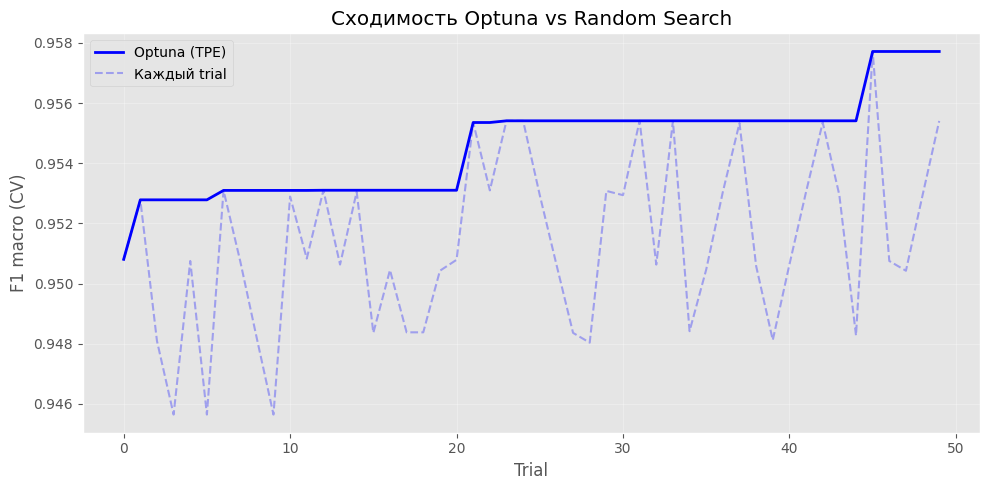

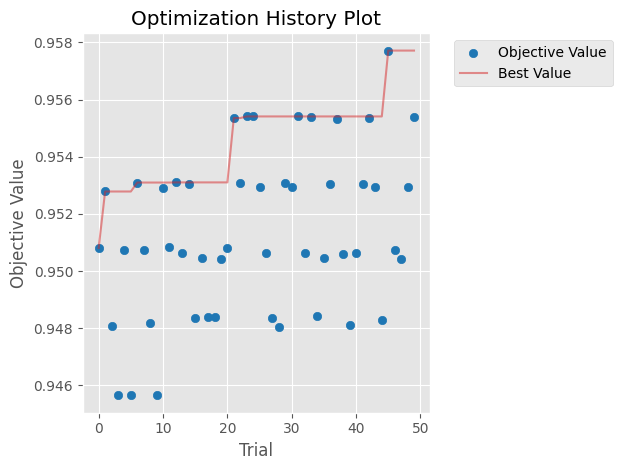

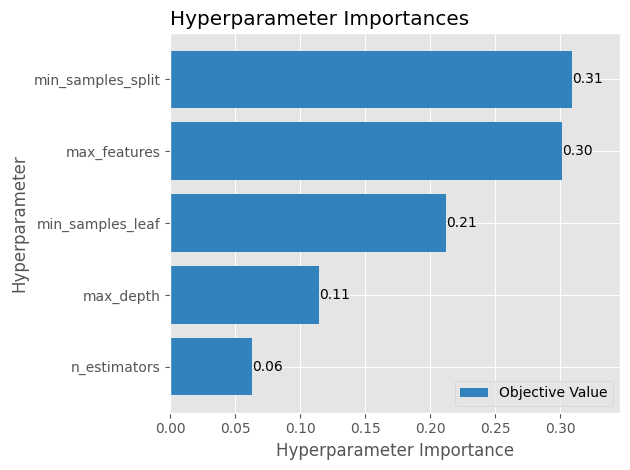

In [42]:
import optuna


optuna.logging.set_verbosity(optuna.logging.WARNING)


# ╔══════════════════════════════════════════════════════════════╗
# ║  БОНУС: Реализуйте objective-функцию для Optuna              ║
# ║  Используйте те же параметры, что в Random Search            ║
# ║  Запустите study.optimize с n_trials=50                      ║
# ║                                                              ║
# ║  Постройте график сходимости:                                ║
# ║  plt.plot(range(n_trials), best_values_over_time)            ║
# ║  Сравните кривые Optuna и Random Search (если логировали)    ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE
def objective(trial):
    # Те же параметры что в RandomSearch
    n_estimators = trial.suggest_int('n_estimators', 100, 500)
    max_depth = trial.suggest_categorical('max_depth', [None, 5, 10, 20, 30])
    min_samples_split = trial.suggest_int('min_samples_split', 2, 20)
    min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 10)
    max_features = trial.suggest_categorical('max_features', ['sqrt', 'log2', None])

    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('rf', RandomForestClassifier(
            n_estimators=n_estimators,
            max_depth=max_depth,
            min_samples_split=min_samples_split,
            min_samples_leaf=min_samples_leaf,
            max_features=max_features,
            random_state=42,
            n_jobs=-1
        ))
    ])

    score = cross_val_score(
        pipeline, X_train, y_train,
        cv=5, scoring='f1_macro', n_jobs=-1
    ).mean()

    return score

n_trials = 50
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=n_trials)

print(f"Лучший результат Optuna: {study.best_value:.4f}")
print(f"Лучшие параметры: {study.best_params}")

# Лучшее значение на каждом шаге (накопленный максимум)
trial_values = [t.value for t in study.trials]
best_values_over_time = np.maximum.accumulate(trial_values)

plt.figure(figsize=(10, 5))
plt.plot(range(n_trials), best_values_over_time,
         label='Optuna (TPE)', color='blue', linewidth=2)
plt.plot(range(n_trials), trial_values,
         alpha=0.3, color='blue', linestyle='--', label='Каждый trial')


plt.xlabel('Trial')
plt.ylabel('F1 macro (CV)')
plt.title('Сходимость Optuna vs Random Search')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

optuna.visualization.matplotlib.plot_optimization_history(study)
plt.tight_layout()
plt.show()

optuna.visualization.matplotlib.plot_param_importances(study)
plt.tight_layout()
plt.show()